# Gaussian Noise 추가

원본 multi-echo GRE complex 데이터에 Gaussian noise를 추가하여 10%, 30%, 50% noise level의 실험 데이터를 생성한다.

원본 데이터는 그대로 유지하고, noise가 추가된 데이터만 별도의 `.mat` 파일로 저장한다.

생성한 noisy 데이터는 이후 Magnitude MP-PCA, Real/Imaginary MP-PCA 등 denoising 실험의 입력 데이터로 사용한다.

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

### 환경설정

In [3]:
data_path = "./data/meas_gre_dir1.mat"

NOISE_LEVELS = [0.1, 0.3, 0.5]
SEED = 50

OUT_DIR = Path("./data/noisy_data")
OUT_DIR.mkdir(parents=True, exist_ok=True)

### 1. 데이터 불러오기

In [5]:
orig_data = sio.loadmat(data_path)

orig_complex = orig_data["meas_gre"]
mask = orig_data["mask_brain"].astype(bool)

print("orig_complex shape:", orig_complex.shape)
print("mask shape:", mask.shape)

n_echoes = orig_complex.shape[-1]

orig_complex shape: (256, 224, 176, 6)
mask shape: (256, 224, 176)


### 2. brain mask 내부 magnitude 평균 계산

In [7]:
mean_signals = []

for c in range(n_echoes):
    orig_mag_echo = np.abs(orig_complex[..., c])
    brain_region = orig_mag_echo[mask]

    mean_signals.append(brain_region.mean())

overall_mean = np.mean(mean_signals)

print("\nEcho별 평균:")
for c, value in enumerate(mean_signals):
    print(f"Echo {c+1}: {value:.6f}")

print(f"\n전체 평균 magnitude: {overall_mean:.6f}")


Echo별 평균:
Echo 1: 3.797068
Echo 2: 3.461442
Echo 3: 3.152384
Echo 4: 2.872445
Echo 5: 2.620200
Echo 6: 2.388488

전체 평균 magnitude: 3.048671


### 3. 10%, 30%, 50% Gaussian noise 생성

In [9]:
results = {}

for noise_ratio in NOISE_LEVELS:
    rng = np.random.default_rng(SEED)

    sigma = overall_mean * noise_ratio
    noise_percent = int(noise_ratio * 100)

    print("\n" + "=" * 50)
    print(f"Noise level : {noise_percent}%")
    print(f"Sigma       : {sigma:.6f}")
    print(f"Seed        : {SEED}")
    print("=" * 50)

    noisy_real_all = np.zeros_like(orig_complex, dtype=np.float32)
    noisy_imag_all = np.zeros_like(orig_complex, dtype=np.float32)

    for c in range(n_echoes):
        orig_echo = orig_complex[..., c]

        orig_real = np.real(orig_echo)
        orig_imag = np.imag(orig_echo)

        noise_real = rng.normal(
            loc=0.0,
            scale=sigma,
            size=orig_real.shape
        )

        noise_imag = rng.normal(
            loc=0.0,
            scale=sigma,
            size=orig_imag.shape
        )

        noise_real_masked = noise_real * mask
        noise_imag_masked = noise_imag * mask

        noisy_real_all[..., c] = orig_real + noise_real_masked
        noisy_imag_all[..., c] = orig_imag + noise_imag_masked

    noisy_complex = (
        noisy_real_all.astype(np.complex64)
        + 1j * noisy_imag_all.astype(np.complex64)
    )

    results[noise_percent] = {
        "noisy_real": noisy_real_all,
        "noisy_imag": noisy_imag_all,
        "noisy_complex": noisy_complex,
        "noise_ratio": noise_ratio,
        "sigma": sigma,
    }

    print(f"{noise_percent}% noise 생성 완료")

print("\n모든 noise 생성 완료")


Noise level : 10%
Sigma       : 0.304867
Seed        : 50
10% noise 생성 완료

Noise level : 30%
Sigma       : 0.914601
Seed        : 50
30% noise 생성 완료

Noise level : 50%
Sigma       : 1.524336
Seed        : 50
50% noise 생성 완료

모든 noise 생성 완료


### 4. Noise 데이터 저장

In [11]:
for noise_percent, result in results.items():

    output_path = (
        OUT_DIR /
        f"noisy_meas_gre_dir1_{noise_percent}.mat"
    )

    save_data = {
        "noisy_real": result["noisy_real"],
        "noisy_imag": result["noisy_imag"],
        "noisy_complex": result["noisy_complex"],
        "mask_brain": orig_data["mask_brain"],
        "noise_ratio": result["noise_ratio"],
        "sigma": result["sigma"],
        "seed": SEED,
        "overall_mean": overall_mean,
        "te_gre": orig_data["te_gre"],
        "delta_TE": orig_data["delta_TE"],
        "voxel_size_gre": orig_data["voxel_size_gre"],
        "B0_dir": orig_data["B0_dir"],
        "CF": orig_data["CF"],
    }

    sio.savemat(output_path, save_data)

    print("저장 완료 →", output_path)

print("\n모든 파일 저장 완료")

저장 완료 → data\noisy_data\noisy_meas_gre_dir1_10.mat
저장 완료 → data\noisy_data\noisy_meas_gre_dir1_30.mat
저장 완료 → data\noisy_data\noisy_meas_gre_dir1_50.mat

모든 파일 저장 완료


### 5. 시각화

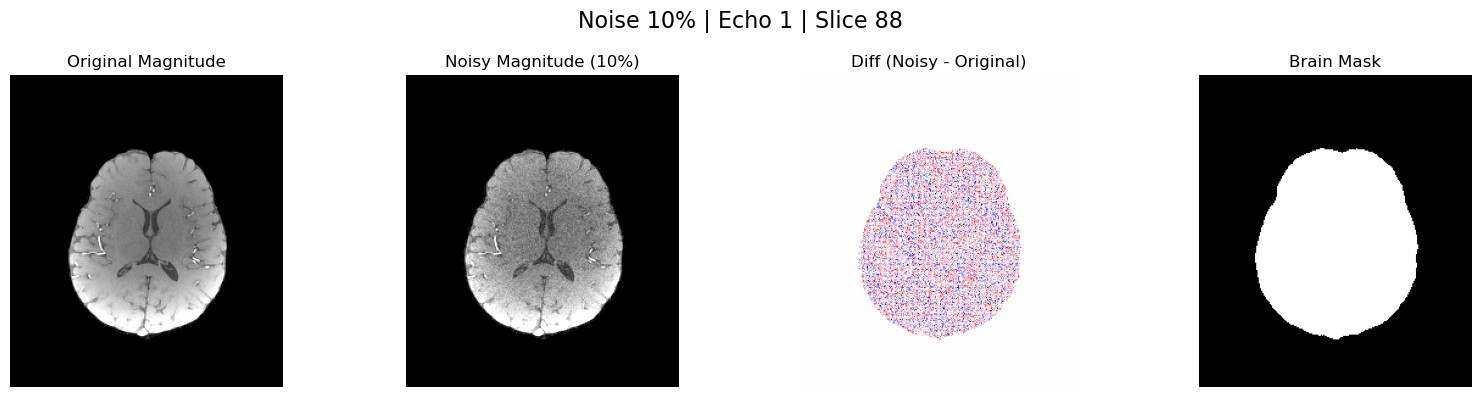

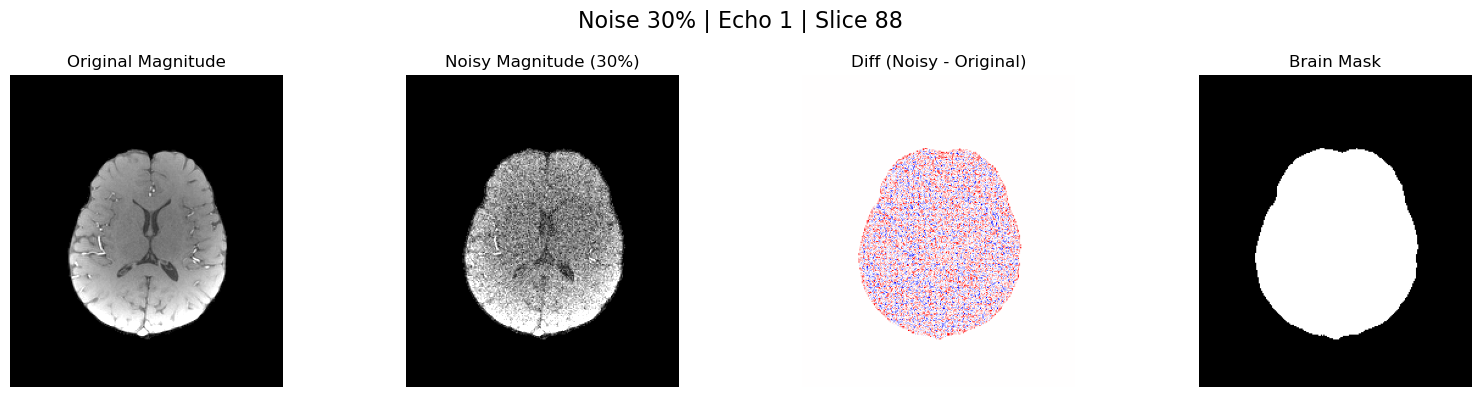

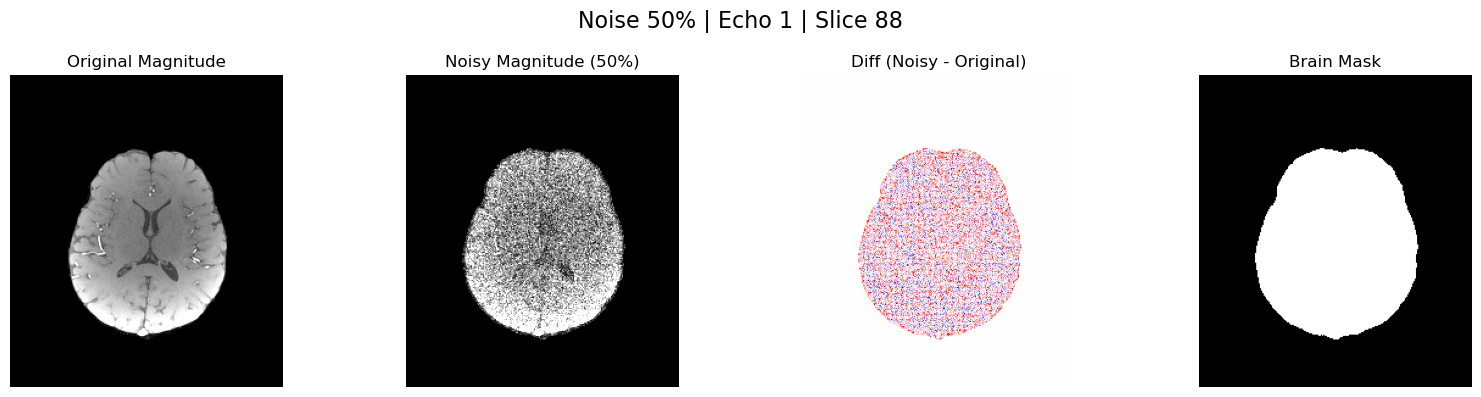

In [13]:
NOISE_PERCENTS = [10, 30, 50]
echo_idx = 0
slice_idx = 88

orig_mag = np.abs(orig_complex).astype(np.float32)

for noise_percent in NOISE_PERCENTS:
    file_path = OUT_DIR / f"noisy_meas_gre_dir1_{noise_percent}.mat"

    noisy_data = sio.loadmat(file_path, simplify_cells=True)

    noisy_complex = noisy_data["noisy_complex"]
    mask_vis = noisy_data["mask_brain"].astype(bool)

    noisy_mag = np.abs(noisy_complex).astype(np.float32)

    orig_2d = orig_mag[:, :, slice_idx, echo_idx]
    noisy_2d = noisy_mag[:, :, slice_idx, echo_idx]
    mask_2d = mask_vis[:, :, slice_idx]

    diff_2d = noisy_2d - orig_2d

    vmin, vmax = np.percentile(
        orig_mag[mask_vis],
        (1, 99)
    )

    dv = np.percentile(
        np.abs(diff_2d[mask_2d]),
        99
    )

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    ax[0].imshow(
        orig_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax[0].set_title("Original Magnitude")
    ax[0].axis("off")

    ax[1].imshow(
        noisy_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax[1].set_title(
        f"Noisy Magnitude ({noise_percent}%)"
    )
    ax[1].axis("off")

    ax[2].imshow(
        diff_2d,
        cmap="bwr",
        vmin=-dv,
        vmax=dv
    )
    ax[2].set_title("Diff (Noisy - Original)")
    ax[2].axis("off")

    ax[3].imshow(
        mask_2d,
        cmap="gray"
    )
    ax[3].set_title("Brain Mask")
    ax[3].axis("off")

    fig.suptitle(
        f"Noise {noise_percent}% | Echo {echo_idx + 1} | Slice {slice_idx}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()